In [1]:
%load_ext autoreload
%autoreload 2

In [117]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LogNorm

In [47]:
from sim.camera import Camera
from sim.lens import Lens
from sim.optics import print_fov
from sim.frame import make_blank_frame, display_frame
from sim.render import RenderConfig, render, plot_render_stages
from sim.physics.stars import load_star_field

In [5]:
cam = Camera(nx=1920, ny=1080, pixel_um=2.9)
lens = Lens(focal_mm=16.0, f_number=1.4)
print_fov(cam, lens)

Sensor: 5.568 mm x 3.132 mm
FOV:    19.939 deg x 11.216 deg
Scale:  37.385 arcsec / px


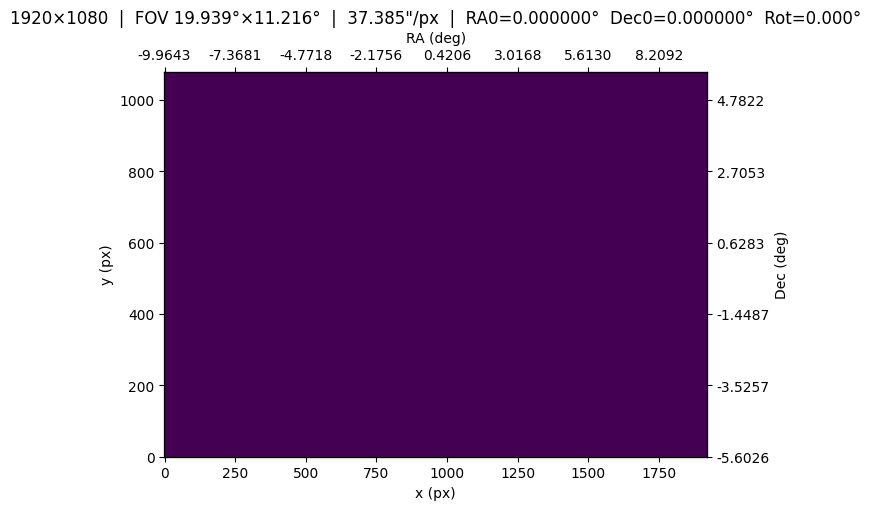

In [33]:
frame = make_blank_frame(cam, lens, ra0_deg=0.0, dec0_deg=0.0, rot_deg=0.0)
cfg = RenderConfig(exposure_s=0.2, sky_e_per_px_s=3, seed=0)

frame, res = render(frame, cfg, stars=None, return_intermediates=True)
display_frame(frame)

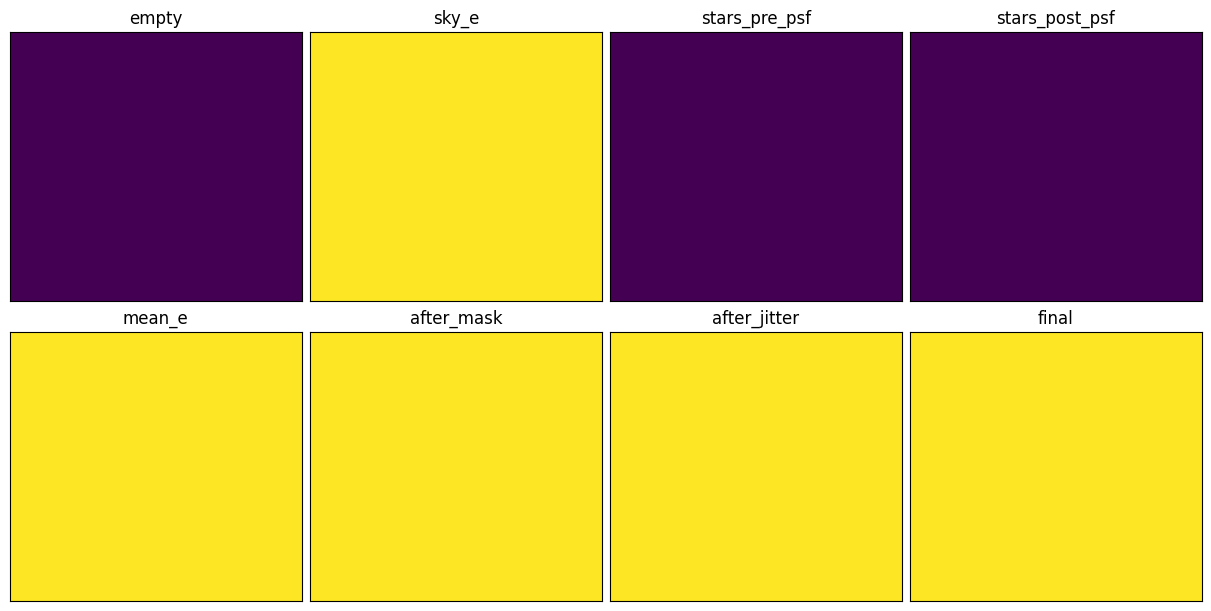

In [34]:
plot_render_stages(frame, res)

In [35]:
res

RenderResult(sky_e=array([[0.6, 0.6, 0.6, ..., 0.6, 0.6, 0.6],
       [0.6, 0.6, 0.6, ..., 0.6, 0.6, 0.6],
       [0.6, 0.6, 0.6, ..., 0.6, 0.6, 0.6],
       ...,
       [0.6, 0.6, 0.6, ..., 0.6, 0.6, 0.6],
       [0.6, 0.6, 0.6, ..., 0.6, 0.6, 0.6],
       [0.6, 0.6, 0.6, ..., 0.6, 0.6, 0.6]], dtype=float32), stars_e_pre_psf=array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32), stars_e_post_psf=array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32), mean_e=array([[0.6, 0.6, 0.6, ..., 0.6, 0.6, 0.6],
       [0.6, 0.6, 0.6, ..., 0.6, 0.6, 0.6],
       [0.6, 0.6, 0.6, ..., 0.6, 0.6, 0.6],
  

In [53]:
sf = load_star_field(r"sim/physics/starfields/field2.csv")

print(sf)
print("Number of stars:", len(sf.ra_deg))
print("First 5 RA:", sf.ra_deg[:5])
print("First 5 Dec:", sf.dec_deg[:5])
print("First 5 mag:", sf.mag[:5])

StarField(ra_deg=array([ 14.177451  ,  21.45661246, 354.83578083, ...,  81.6610312 ,
        55.65185687,  35.34355105]), dec_deg=array([60.7167228 , 60.23506761, 77.63312481, ..., 71.43324093,
       68.96389973, 56.96512575]), mag=array([ 2.0645833,  2.6805298,  2.9429574, ..., 11.999938 , 11.999974 ,
       11.999997 ]), meta={'source': 'sim\\physics\\starfields\\field2.csv'})
Number of stars: 65263
First 5 RA: [ 14.177451    21.45661246 354.83578083  42.67433779  57.38032653]
First 5 Dec: [60.7167228  60.23506761 77.63312481 55.89543429 65.52591009]
First 5 mag: [2.0645833 2.6805298 2.9429574 3.1448548 3.267435 ]


Total catalog stars: 65263
Stars on sensor: 517
Derived zeropoint ~ 1.370e+07 e-/s (mag=0)
Electrons per star (on-sensor): min=2.174e+04, median=4.986e+04, max=4.414e+06


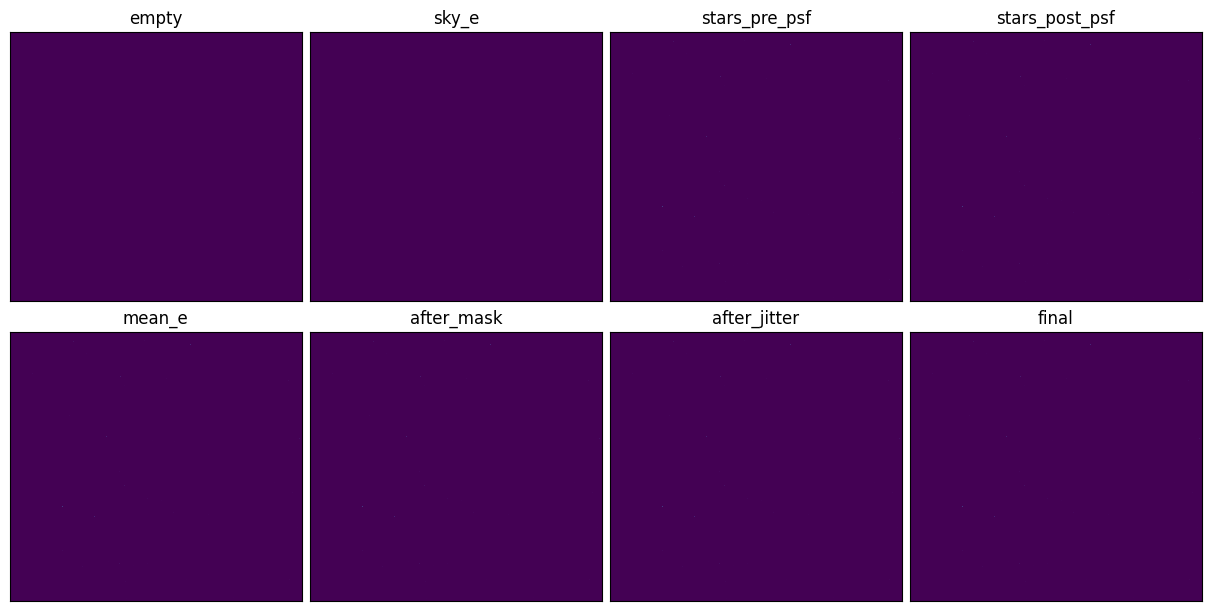

In [83]:
# ---- point this at your local CSV ----
STAR_CSV = r"sim/physics/starfields/field2.csv"

# ---- pick a pointing that matches the field you downloaded ----
RA0_DEG  = 40.0
DEC0_DEG = 70.0
ROT_DEG  = 0.0

# ---- camera + lens (example values; adjust to your actual setup) ----
cam = Camera(
    nx=1920,
    ny=1080,
    pixel_um=3.75,
    read_noise_e=0.0,
    gain_e_per_adu=1.0,
    qe=0.6,   # if you want this to be your assumed QE
)

lens = Lens(
    focal_mm=120.0,
    f_number=2.0,
    transmission=0.9
)

frame = make_blank_frame(cam, lens, ra0_deg=RA0_DEG, dec0_deg=DEC0_DEG, rot_deg=ROT_DEG)

cfg = RenderConfig(
    exposure_s=100,
    sky_e_per_px_s=3.0,
    zeropoint_e_per_s=0,   # 0 => derive from optics
    enable_psf=False,
    enable_mask=False,
    enable_jitter=False,
    enable_noise=False,
)

# ---- render ----
frame, res = render(frame, cfg, stars=STAR_CSV)

# ---- visualize ----
plot_render_stages(frame, res, shared_scale=False, show_colorbar=False)

# ---- sanity checks ----
sf = load_star_field(STAR_CSV)
x_px, y_px = frame.radec_to_pixel(sf.ra_deg, sf.dec_deg)

on = (x_px >= 0) & (x_px < cam.nx) & (y_px >= 0) & (y_px < cam.ny)
print("Total catalog stars:", len(sf.ra_deg))
print("Stars on sensor:", int(on.sum()))

# electrons summary (using same model as stars_layer)
# (this reproduces the derived ZP logic without importing internals)


def derive_zp(lens, qe, lambda_eff_nm=550.0, band_nm=90.0):
    h = 6.62607015e-34
    c = 2.99792458e8
    lam = lambda_eff_nm * 1e-9
    dlam = band_nm * 1e-9
    F0_W_m2_m = 3.6e-2
    f_m = lens.focal_mm * 1e-3
    D_m = f_m / lens.f_number
    A_m2 = math.pi * (0.5 * D_m) ** 2
    E_ph = h * c / lam
    photons_s_m2 = (F0_W_m2_m * dlam) / E_ph
    return photons_s_m2 * A_m2 * lens.transmission * qe

zp = derive_zp(lens, cam.qe, cfg.lambda_eff_nm, cfg.band_nm)
mag_on = sf.mag[on]
e_on = cfg.exposure_s * zp * (10.0 ** (-0.4 * mag_on))

print(f"Derived zeropoint ~ {zp:.3e} e-/s (mag=0)")
if e_on.size > 0:
    print(f"Electrons per star (on-sensor): min={e_on.min():.3e}, median={np.median(e_on):.3e}, max={e_on.max():.3e}")

In [85]:
res.stars_e_pre_psf

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

In [84]:
for x in (res.stars_e_pre_psf):
    for y in x:
        if y > 0:
            print(y)

1474.634
8903.285
20716.133
519.21796
12938.786
167337.34
3910.167
98.00231
21457.188
277505.84
31.564194
14319.637
23265.645
24798.793
14685.907
9877.807
15710.226
8416.879
18.132004
8225.894
1005.1419
12876.587
76474.39
81513.87
15329.032
10310.375
2811.2124
1506.1294
300577.22
322338.66
8254.072
105740.57
11512.246
4469.437
719862.56
771979.7
6774.649
1660.6913
14600.386
5668.3555
235023.31
35310.633
16630.027
16439.215
13818.023
3387.256
23001.713
3455.8486
3377.3984
3338.6462
4984.1143
10932.086
6894.0273
15121.263
542.905
309.7788
16572.68
9456.285
82619.97
6914.686
44605.77
3733.1763
15295.942
29302.299
1838.1538
3521.335
2033.243
2117.7866
9384.318
9774.525
76545.6
92671.57
112556.23
136268.6
17152.574
6190.5005
7772.703
35729.7
15005.702
5415.6772
5100.243
23444.887
79286.766
25865.707
4267.3203
1096.7557
22045.72
7191.9717
18293.32
4701.616
12020.307
4915.6733
5354.3774
2189.659
10269.647
1241.7793
64119.707
77482.32
16017.091
1936.7455
9854.781
11908.528
17540.17
9981.519
48

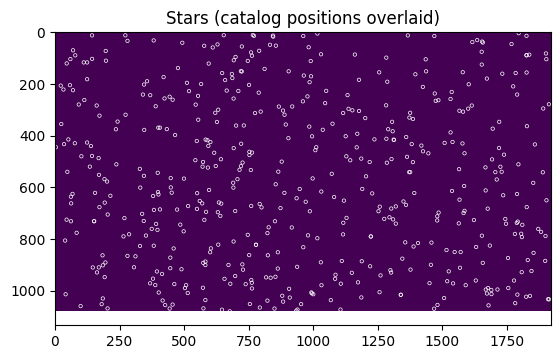

In [88]:
plt.figure()
plt.imshow(img, vmin=0, vmax=np.percentile(img, 99.9))
plt.scatter(x_px[on], y_px[on], s=6, facecolors="none", edgecolors="w", linewidths=0.5)
plt.title("Stars (catalog positions overlaid)")
plt.show()

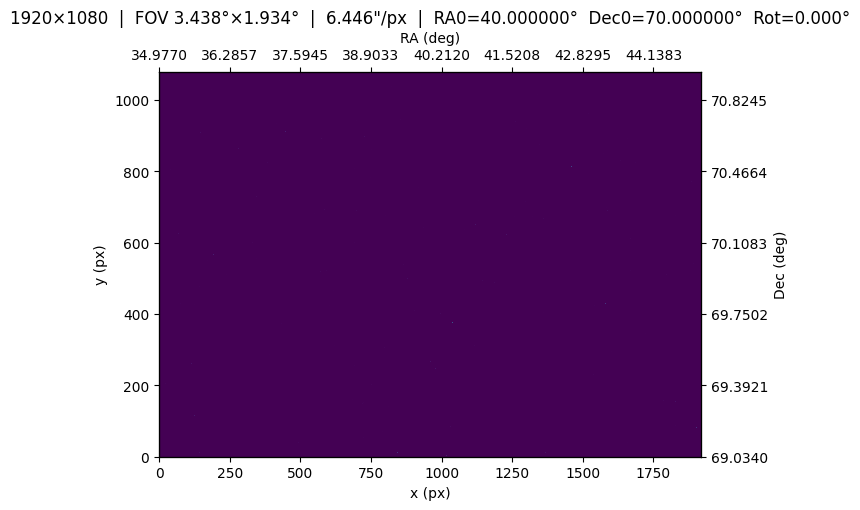

In [90]:
display_frame(frame)

In [91]:
frame

Frame(camera=Camera(nx=1920, ny=1080, pixel_um=3.75, read_noise_e=0.0, gain_e_per_adu=1.0, qe=0.6), lens=Lens(focal_mm=120.0, f_number=2.0, transmission=0.9), image=array([[300., 300., 300., ..., 300., 300., 300.],
       [300., 300., 300., ..., 300., 300., 300.],
       [300., 300., 300., ..., 300., 300., 300.],
       ...,
       [300., 300., 300., ..., 300., 300., 300.],
       [300., 300., 300., ..., 300., 300., 300.],
       [300., 300., 300., ..., 300., 300., 300.]], dtype=float32), x_rad=array([[-0.02998438, -0.02995313, -0.02992188, ...,  0.02992188,
         0.02995313,  0.02998438],
       [-0.02998438, -0.02995313, -0.02992188, ...,  0.02992188,
         0.02995313,  0.02998438],
       [-0.02998438, -0.02995313, -0.02992188, ...,  0.02992188,
         0.02995313,  0.02998438],
       ...,
       [-0.02998438, -0.02995313, -0.02992188, ...,  0.02992188,
         0.02995313,  0.02998438],
       [-0.02998438, -0.02995313, -0.02992188, ...,  0.02992188,
         0.02995313,  0

In [96]:
np.max(res.final_e)

2116999.0

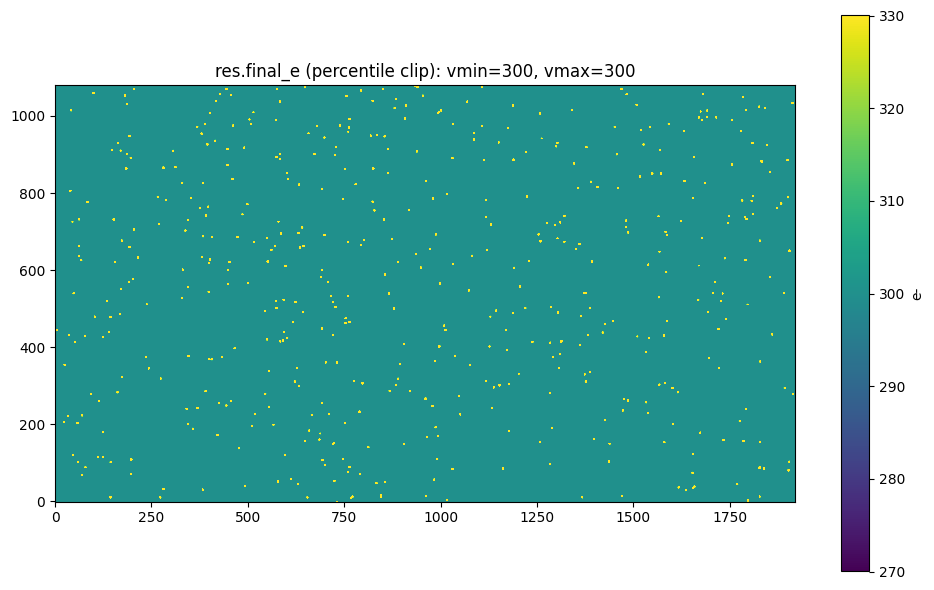

In [97]:
img = res.final_e

vmin, vmax = np.percentile(img, [5, 99.9])   # tweak 99.9 -> 99.5 if a few pixels dominate

plt.figure(figsize=(10, 6))
plt.imshow(img, origin="lower", vmin=vmin, vmax=vmax)
plt.colorbar(label="e-")
plt.title(f"res.final_e (percentile clip): vmin={vmin:.3g}, vmax={vmax:.3g}")
plt.tight_layout()
plt.show()

In [125]:
# ---- PSF visibility test: render with/without PSF and compare stages ----
import numpy as np
import matplotlib.pyplot as plt

# 1) Render with PSF OFF (so stars are mostly single-pixel spikes)
cfg_no_psf = RenderConfig(
    exposure_s=100.0,
    sky_e_per_px_s=3.0,
    zeropoint_e_per_s=0,   # keep whatever you're using for now
    enable_psf=False,
    enable_mask=False,
    enable_jitter=False,
    enable_noise=False,
)

frame0 = make_blank_frame(cam, lens, ra0_deg=RA0_DEG, dec0_deg=DEC0_DEG, rot_deg=ROT_DEG)
frame0, res0 = render(frame0, cfg_no_psf, stars=STAR_CSV)

print("NO PSF: stars_pre_psf sum/max:",
      float(np.sum(res0.stars_e_pre_psf)), float(np.max(res0.stars_e_pre_psf)))

plot_render_stages(
    frame0, res0,
    shared_scale=False,      # important: don't let one hot pixel kill visibility
    show_colorbar=False
)

# 2) Render with PSF ON (stars should become multi-pixel blobs)
cfg_psf = RenderConfig(
    exposure_s=100.0,
    sky_e_per_px_s=3.0,
    zeropoint_e_per_s=0,
    psf_sigma_px=1.2,         # tweak: try 0.8, 1.2, 2.0
    enable_psf=True,
    enable_mask=False,
    enable_jitter=False,
    enable_noise=False,
)

frame1 = make_blank_frame(cam, lens, ra0_deg=RA0_DEG, dec0_deg=DEC0_DEG, rot_deg=ROT_DEG)
frame1, res1 = render(frame1, cfg_psf, stars=STAR_CSV)

print("WITH PSF: stars_pre_psf sum/max:",
      float(np.sum(res1.stars_e_pre_psf)), float(np.max(res1.stars_e_pre_psf)))
print("WITH PSF: stars_post_psf sum/max:",
      float(np.sum(res1.stars_e_post_psf)), float(np.max(res1.stars_e_post_psf)))

# flux conservation check (should be ~equal)
s_pre  = float(np.sum(res1.stars_e_pre_psf))
s_post = float(np.sum(res1.stars_e_post_psf))
print("Flux ratio (post/pre):", s_post / max(1e-12, s_pre))

plot_render_stages(
    frame1, res1,
    shared_scale=False,
    show_colorbar=False
)

# 3) Optional: a stretched view of the final images (makes the difference obvious)
def show_percentile(img, title, lo=5, hi=99.9):
    vmin, vmax = np.percentile(img[np.isfinite(img)], [lo, hi])
    plt.figure(figsize=(9, 5))
    plt.imshow(img, origin="lower", vmin=vmin, vmax=vmax, interpolation="nearest", aspect="auto")
    plt.colorbar(label="e-")
    plt.title(f"{title} (p{lo}–p{hi} stretch)")
    plt.tight_layout()
    plt.show()

show_percentile(res0.final_e, "Final (NO PSF)")
show_percentile(res1.final_e, "Final (WITH PSF)")

NO PSF: stars_pre_psf sum/max: 66814644.0 2116699.0


TypeError: plot_render_stages() missing 5 required keyword-only arguments: 'stretch', 'ref_stage', 'q_lo', 'q_hi', and 'eps'

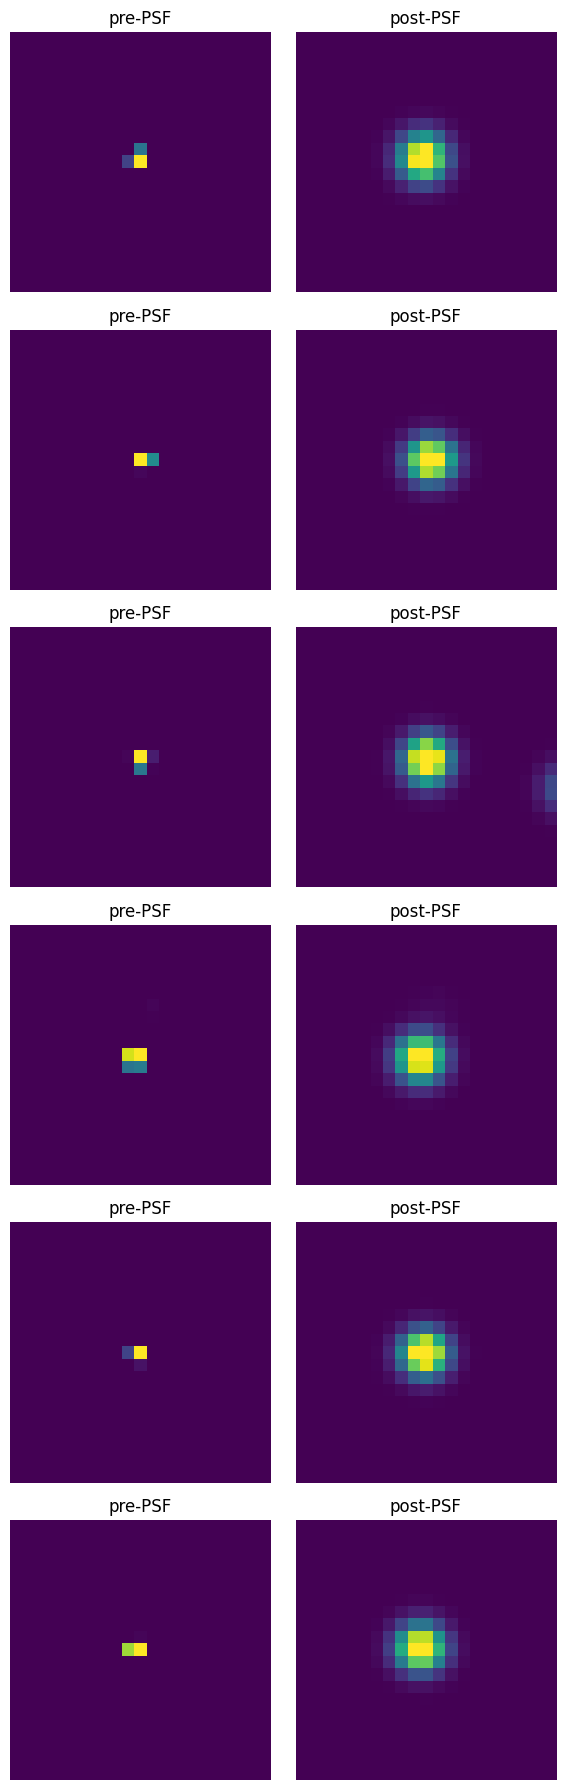

In [101]:
# ---- Zoom-in PSF inspection on brightest stars ----
# use the PSF-enabled render result
img_pre  = res1.stars_e_pre_psf
img_post = res1.stars_e_post_psf

# find brightest star pixels (pre-PSF image)
flat_inds = np.argsort(img_pre.ravel())[::-1]  # descending
ny, nx = img_pre.shape

# number of stars to inspect
N_show = 6
half_size = 10   # half-width of zoom box in pixels

# collect unique star centers (avoid duplicates from same star)
centers = []
used = np.zeros_like(img_pre, dtype=bool)

for ind in flat_inds:
    if len(centers) >= N_show:
        break
    y = ind // nx
    x = ind % nx

    if img_pre[y, x] <= 0:
        break

    # avoid picking multiple pixels from same star
    if not used[y, x]:
        centers.append((y, x))
        y0 = max(0, y-half_size)
        y1 = min(ny, y+half_size+1)
        x0 = max(0, x-half_size)
        x1 = min(nx, x+half_size+1)
        used[y0:y1, x0:x1] = True

fig, axs = plt.subplots(N_show, 2, figsize=(6, 3*N_show))

for k, (y, x) in enumerate(centers):

    y0 = max(0, y-half_size)
    y1 = min(ny, y+half_size+1)
    x0 = max(0, x-half_size)
    x1 = min(nx, x+half_size+1)

    cut_pre  = img_pre[y0:y1, x0:x1]
    cut_post = img_post[y0:y1, x0:x1]

    # percentile stretch for visibility
    def stretch(a):
        lo, hi = np.percentile(a[a>0], [5, 99.5]) if np.any(a>0) else (0,1)
        return a, lo, hi

    _, vmin_pre, vmax_pre   = stretch(cut_pre)
    _, vmin_post, vmax_post = stretch(cut_post)

    axs[k,0].imshow(cut_pre, origin="lower",
                    vmin=vmin_pre, vmax=vmax_pre)
    axs[k,0].set_title("pre-PSF")
    axs[k,0].axis("off")

    axs[k,1].imshow(cut_post, origin="lower",
                    vmin=vmin_post, vmax=vmax_post)
    axs[k,1].set_title("post-PSF")
    axs[k,1].axis("off")

plt.tight_layout()
plt.show()

Exposure scaling check:
  t=  10s  total_e=9.752e-01   peak_e=5.899e-03
  t=  20s  total_e=1.950e+00   peak_e=1.180e-02
  t=  50s  total_e=4.876e+00   peak_e=2.950e-02
  t= 100s  total_e=9.752e+00   peak_e=5.899e-02
  t= 200s  total_e=1.950e+01   peak_e=1.180e-01

Total flux ratios: [ 1.         2.         4.9999986  9.999997  19.999994 ]
Expected ratios   : [ 1.  2.  5. 10. 20.]


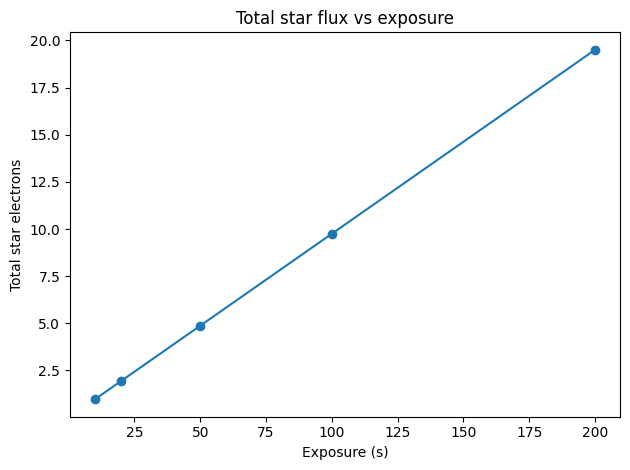


Zeropoint scaling check:
  ZP=0.50  total_e=2.438e+00
  ZP=1.00  total_e=4.876e+00
  ZP=2.00  total_e=9.752e+00
  ZP=5.00  total_e=2.438e+01

Total flux ratios: [ 1.  2.  4. 10.]
Expected ratios   : [ 1.  2.  4. 10.]


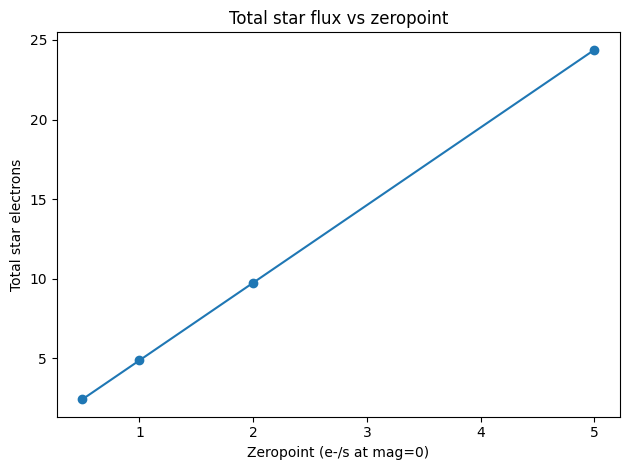


PSF flux conservation:
  pre-PSF total : 9.756283
  post-PSF total: 9.752104
  ratio (post/pre): 0.9995717


In [104]:
# ---- PHYSICAL SCALING TESTS ----
import numpy as np
import matplotlib.pyplot as plt

def run_case(exposure_s, zeropoint=2.0):
    cfg_test = RenderConfig(
        exposure_s=exposure_s,
        sky_e_per_px_s=0.0,      # isolate stars only
        zeropoint_e_per_s=zeropoint,
        psf_sigma_px=1.2,
        enable_psf=True,
        enable_mask=False,
        enable_jitter=False,
        enable_noise=False,
    )
    fr = make_blank_frame(cam, lens,
                          ra0_deg=RA0_DEG,
                          dec0_deg=DEC0_DEG,
                          rot_deg=ROT_DEG)
    fr, res = render(fr, cfg_test, stars=STAR_CSV)
    return res

# -------------------------------------------------
# 1) Exposure time scaling test
# -------------------------------------------------
exposures = [10, 20, 50, 100, 200]

totals = []
peaks  = []

for t in exposures:
    res = run_case(t)
    totals.append(np.sum(res.stars_e_post_psf))
    peaks.append(np.max(res.stars_e_post_psf))

totals = np.array(totals)
peaks  = np.array(peaks)

print("Exposure scaling check:")
for t, tot, pk in zip(exposures, totals, peaks):
    print(f"  t={t:4.0f}s  total_e={tot:.3e}   peak_e={pk:.3e}")

# linearity check
ratios = totals / totals[0]
expected = np.array(exposures) / exposures[0]
print("\nTotal flux ratios:", ratios)
print("Expected ratios   :", expected)

# plot
plt.figure()
plt.plot(exposures, totals, 'o-')
plt.xlabel("Exposure (s)")
plt.ylabel("Total star electrons")
plt.title("Total star flux vs exposure")
plt.tight_layout()
plt.show()


# -------------------------------------------------
# 2) Zeropoint scaling test
# -------------------------------------------------
zeropoints = [0.5, 1.0, 2.0, 5.0]

totals_zp = []

for zp in zeropoints:
    res = run_case(100, zeropoint=zp)
    totals_zp.append(np.sum(res.stars_e_post_psf))

totals_zp = np.array(totals_zp)

print("\nZeropoint scaling check:")
for zp, tot in zip(zeropoints, totals_zp):
    print(f"  ZP={zp:.2f}  total_e={tot:.3e}")

ratios_zp = totals_zp / totals_zp[0]
expected_zp = np.array(zeropoints) / zeropoints[0]

print("\nTotal flux ratios:", ratios_zp)
print("Expected ratios   :", expected_zp)

plt.figure()
plt.plot(zeropoints, totals_zp, 'o-')
plt.xlabel("Zeropoint (e-/s at mag=0)")
plt.ylabel("Total star electrons")
plt.title("Total star flux vs zeropoint")
plt.tight_layout()
plt.show()


# -------------------------------------------------
# 3) PSF flux conservation check
# -------------------------------------------------
res = run_case(100)

pre  = np.sum(res.stars_e_pre_psf)
post = np.sum(res.stars_e_post_psf)

print("\nPSF flux conservation:")
print("  pre-PSF total :", pre)
print("  post-PSF total:", post)
print("  ratio (post/pre):", post / pre)

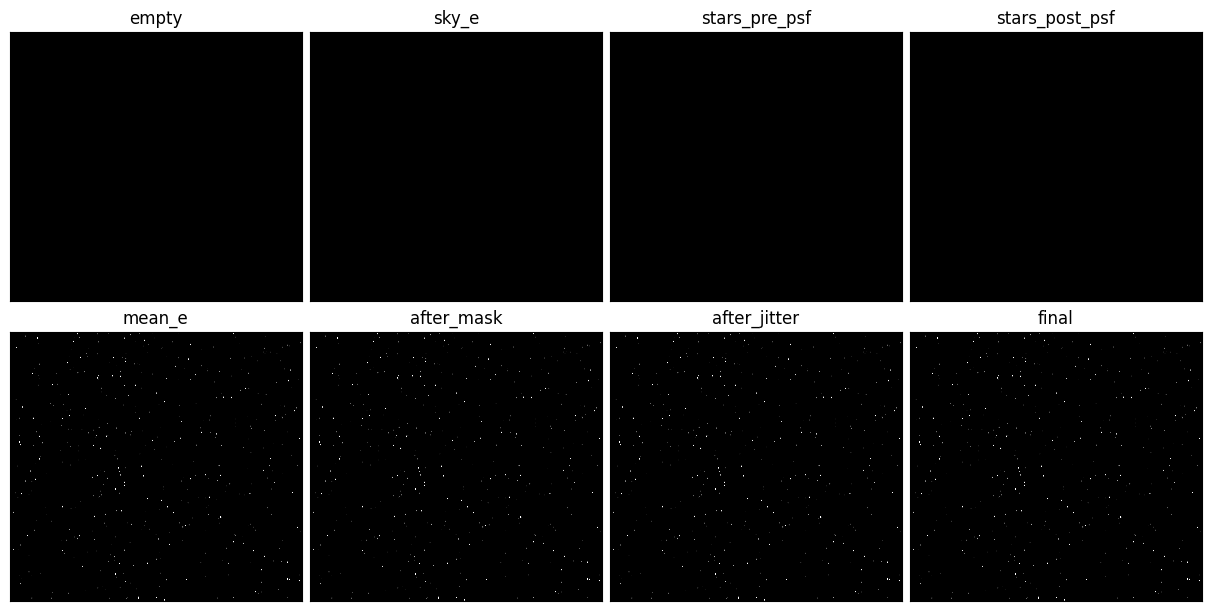

In [126]:
# re-render (or reuse your existing frame/res)
frame_test = make_blank_frame(cam, lens, ra0_deg=RA0_DEG, dec0_deg=DEC0_DEG, rot_deg=ROT_DEG)
frame_test, res_test = render(frame_test, cfg_psf, stars=STAR_CSV)

# new plot: should show stars in wide panels now
plot_render_stages(frame_test, res_test,
                   cmap="gray",
                   stretch="asinh",
                   ref_stage="final",
                   shared_scale=True,
                   show_colorbar=False,
                   q_lo=5.0,
                   q_hi=99.9,
                   eps=1e-12)

In [130]:
res_test.stars_e_pre_psf

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

In [128]:
cfg_psf

RenderConfig(exposure_s=100.0, sky_e_per_px_s=3.0, zeropoint_e_per_s=2.0, lambda_eff_nm=550.0, band_nm=90.0, psf_sigma_px=1.2, read_noise_e=0.0, jitter_sigma_px=0.0, enable_sky=True, enable_stars=True, enable_psf=True, enable_mask=False, enable_jitter=False, enable_noise=False, seed=0)

In [129]:
print(np.min(img), np.median(img), np.max(img))

-4.5312627e-18 2.6964614e-21 0.0589947


In [ ]:
from sim.camera import Camera
from sim.lens import Lens
from sim.frame import make_blank_frame
from sim.render import render, RenderConfig
from sim.physics.stars import derive_zeropoint_e_per_s

STAR_CSV = "sim/physics/starfields/field2.csv"

RA0_DEG  = 40.0
DEC0_DEG = 70.0
ROT_DEG  = 0.0

cam = Camera(
    nx=1920, ny=1080,
    pixel_um=3.75,
    read_noise_e=0.0,
    gain_e_per_adu=1.0,
    qe=0.6,
)

lens = Lens(
    focal_mm=120.0,
    f_number=2.0,
    transmission=0.9
)

# compute derived ZP directly (same function stars_layer uses)
zp_der = derive_zeropoint_e_per_s(lens, cam.qe, lambda_eff_nm=550.0, band_nm=90.0)
print("Derived zeropoint (mag=0):", zp_der, "e-/s")

def run_case(zp_override, exposure_s=1.0):
    cfg = RenderConfig(
        exposure_s=exposure_s,
        sky_e_per_px_s=3.0,
        zeropoint_e_per_s=zp_override,  # 2.0 => override; 0.0 => derive
        psf_sigma_px=1.2,
        enable_psf=True,
        enable_mask=False,
        enable_jitter=False,
        enable_noise=False,
    )
    frame = make_blank_frame(cam, lens, ra0_deg=RA0_DEG, dec0_deg=DEC0_DEG, rot_deg=ROT_DEG)
    frame, res = render(frame, cfg, stars=STAR_CSV)
    return cfg, frame, res

# --- A) Your current toy zeropoint ---
cfgA, frameA, resA = run_case(zp_override=2.0, exposure_s=100.0)
print("\nOverride ZP=2.0, exposure=100s")
print("stars_pre max:", float(np.max(resA.stars_e_pre_psf)))
print("stars_post max:", float(np.max(resA.stars_e_post_psf)))
print("mean max:", float(np.max(resA.mean_e)))

# --- B) Derived zeropoint (set override to 0.0) ---
# Use shorter exposure to avoid insane values while testing.
cfgB, frameB, resB = run_case(zp_override=0.0, exposure_s=0.01)
print("\nDerived ZP (override=0.0), exposure=0.01s")
print("stars_pre max:", float(np.max(resB.stars_e_pre_psf)))
print("stars_post max:", float(np.max(resB.stars_e_post_psf)))
print("mean max:", float(np.max(resB.mean_e)))

# --- quick zoom on brightest star (post-PSF) for derived case ---
img_pre = resB.stars_e_pre_psf
img_post = resB.stars_e_post_psf
y0, x0 = np.unravel_index(np.argmax(img_pre), img_pre.shape)
half = 12
cut = img_post[max(0,y0-half):y0+half+1, max(0,x0-half):x0+half+1]

plt.figure(figsize=(4,4))
plt.imshow(cut, origin="lower", cmap="gray")
plt.title("Derived ZP: post-PSF zoom (linear)")
plt.axis("off")
plt.tight_layout()
plt.show()